# 07 - Game features (Stage 1)

This builds a game-level table, one row per game, anchored on the set of games that actually appear in the ownership panel (`user_items_df`). That set `I` is the universe the latent-factor preference model can estimate from interactions, so it is the natural anchor. Onto `I` we left-join three sources, each pre-aggregated to the item level first:

- ownership and playtime aggregates from `user_items_df`,
- bundle membership and the standalone snapshot price from `bundle_items_df`,
- Steam catalogue metadata (genres, tags, price, release date) from `steam_games.json`.

A game can appear in several bundles, so the bundle table is collapsed to one row per game before joining (otherwise the join would duplicate game rows). We keep availability flags and retain missingness rather than dropping games. The output feeds notebook 08.

In [2]:
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The game universe: distinct items in the ownership panel

We only need the item id and playtime columns from the large ownership table, so we read just those to keep memory down.

In [3]:
user_items_df = pd.read_csv('../outputs/tables/user_items_df.csv',
                            usecols=['item_id', 'playtime_forever'],
                            dtype={'item_id': str})
print('ownership rows:', f'{len(user_items_df):,}')

item_universe = pd.Index(user_items_df['item_id'].unique(), name='item_id')
print('distinct games in panel (universe I):', f'{len(item_universe):,}')

ownership rows: 5,094,082
distinct games in panel (universe I): 10,978


## Ownership and playtime aggregates

Ownership count (popularity) is the number of owners per game; the panel is already de-duplicated on (user, game) in notebook 02, so a row count per game is an owner count. We also summarize playtime and the share of owners with any recorded playtime.

In [4]:
g = user_items_df.groupby('item_id', sort=False)
own = pd.DataFrame({
    'ownership_count': g.size(),
    'playtime_mean': g['playtime_forever'].mean(), # insane right skew (median is more representative)
    'playtime_median': g['playtime_forever'].median(),
    'playtime_total': g['playtime_forever'].sum(),
    'nonzero_playtime_share': g['playtime_forever'].apply(lambda s: float((s > 0).mean())),
}) # s > 0 to avoid counting users who have the game but never played it
print(own.describe().round(2))

       ownership_count  playtime_mean  playtime_median  playtime_total  \
count         10978.00       10978.00         10978.00    1.097800e+04   
mean            464.03         277.57           113.93    4.596214e+05   
std            1793.59         994.86           794.38    9.301024e+06   
min               1.00           0.00             0.00    0.000000e+00   
25%               9.00          13.58             0.00    2.402500e+02   
50%              43.00          89.26             5.00    3.653500e+03   
75%             220.00         204.89            77.00    2.202425e+04   
max           49136.00       38283.00         45818.00    7.757848e+08   

       nonzero_playtime_share  
count                10978.00  
mean                     0.51  
std                      0.31  
min                      0.00  
25%                      0.24  
50%                      0.53  
75%                      0.75  
max                      1.00  


## Bundle membership, pre-aggregated to one row per game

`bundle_items_df` has one row per bundle-item pair, so a game in several bundles appears several times. We collapse to one row per game: how many bundles contain it, the median standalone snapshot price, and whether the price disagrees across bundles (kept rather than silently resolved). The 10 DLC items with no Steam `item_id` are dropped from this join.

In [5]:
bundle_items_df = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                              dtype={'bundle_id': str, 'item_id': str})
n_dlc = bundle_items_df['item_id'].isna().sum()
bi = bundle_items_df.dropna(subset=['item_id']).copy()
print('bundle-item rows:', len(bundle_items_df), '\ndropped DLC rows without item_id:', int(n_dlc))

bg = bi.groupby('item_id')
bundle_features = pd.DataFrame({
    'bundle_count': bg['bundle_id'].nunique(),
    'item_price_median': bg['item_price'].median(),
    'item_price_nunique': bg['item_price'].nunique(),
})
bundle_features['price_disagreement'] = bundle_features['item_price_nunique'] > 1
print('distinct games appearing in bundles:', len(bundle_features))
print('games with disagreeing snapshot prices across bundles:', # i'm just gonna take the median price (item_price_median)
      int(bundle_features['price_disagreement'].sum()))

bundle-item rows: 3525 
dropped DLC rows without item_id: 10
distinct games appearing in bundles: 2797
games with disagreeing snapshot prices across bundles: 5


## Steam catalogue metadata

`steam_games.json` is line-delimited Python dicts (single quotes), so we parse each line with `ast.literal_eval`, not `json.load`. We keep genres, tags, price, and release date, deduplicate by the canonical string app id, and report how many lines fail to parse and how many duplicate ids we collapse.

In [11]:
records = []
parse_failures = 0
with open('../data/raw/steam_games.json', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            d = ast.literal_eval(line)
        except (ValueError, SyntaxError):
            parse_failures += 1
            continue
        if not isinstance(d, dict) or 'id' not in d:
            continue
        records.append({
            'item_id': str(d['id']),
            'genres': ', '.join(d['genres']) if isinstance(d.get('genres'), list) else d.get('genres'),
            'tags': ', '.join(d['tags']) if isinstance(d.get('tags'), list) else d.get('tags'),
            'steam_price': d.get('price'),
            'release_date': d.get('release_date'),
        })
steam = pd.DataFrame.from_records(records)
n_dup = int(steam['item_id'].duplicated().sum())
steam = steam.drop_duplicates(subset='item_id', keep='first').set_index('item_id')
print('steam metadata rows:', len(steam), 
      '\nparse failures:', parse_failures,
      '\nduplicate ids collapsed:', n_dup)

steam metadata rows: 32132 
parse failures: 0 
duplicate ids collapsed: 1


## Assemble: left-join onto the game universe, with availability flags

Everything is left-joined onto `I`, so games in the panel that lack bundle or catalogue information are kept with missing values rather than dropped. We add explicit flags and a single standalone price (bundle snapshot first, else the catalogue price).

In [ ]:
game_features = pd.DataFrame(index=item_universe)
game_features = game_features.join(own)
game_features = game_features.join(bundle_features)
game_features = game_features.join(steam)

game_features['in_bundle'] = game_features['bundle_count'].fillna(0) > 0
game_features['bundle_count'] = game_features['bundle_count'].fillna(0).astype(int)
game_features['has_steam_metadata'] = game_features['genres'].notna() | game_features['tags'].notna()

def to_price(x):
    # catalogue price can be a number or a string like 'Free to Play'
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan
steam_price_num = game_features['steam_price'].map(to_price)
game_features['standalone_price'] = game_features['item_price_median'].fillna(steam_price_num)
game_features['has_price'] = game_features['standalone_price'].notna()

print('game_features shape:', game_features.shape)
print(game_features[['ownership_count', 'in_bundle', 'has_steam_metadata', 'has_price']].head())

game_features shape: (10978, 17)
         ownership_count  in_bundle  has_steam_metadata  has_price
item_id                                                           
10                  9611      False                True       True
20                  6268       True                True       True
30                  3431       True                True       True
40                  3242       True                True       True
50                  6216       True                True       True


## Reconciliation and sanity checks

The number of distinct in-bundle games in `game_features` must equal the number of distinct non-null bundle `item_id`s that intersect the panel universe `I` (not the bundle-item row count, since one game can sit in many bundles). We also confirm one row per game.

In [20]:
assert game_features.index.is_unique, 'expected one row per game'
assert len(game_features) == len(item_universe)

bundle_ids_in_panel = set(bi['item_id'].unique()) & set(item_universe)
n_in_bundle_features = int(game_features['in_bundle'].sum())
print('distinct in-bundle games in game_features:', n_in_bundle_features)
print('distinct bundle item_ids intersecting the panel:', len(bundle_ids_in_panel))
assert n_in_bundle_features == len(bundle_ids_in_panel)

print('\ncoverage of availability flags:')
print((game_features[['in_bundle', 'has_steam_metadata', 'has_price']].mean().round(3)))

distinct in-bundle games in game_features: 1394
distinct bundle item_ids intersecting the panel: 1394

coverage of availability flags:
in_bundle             0.127
has_steam_metadata    0.837
has_price             0.779
dtype: float64


## Diagnostics

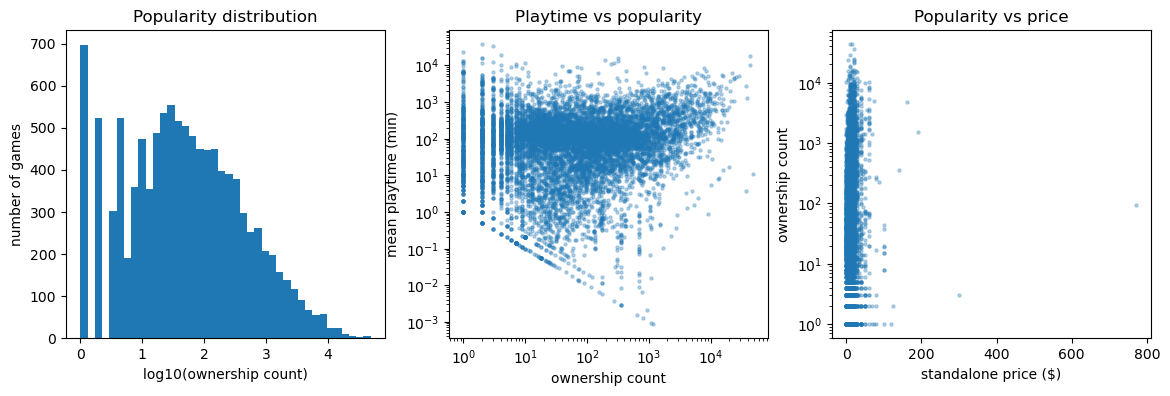

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(np.log10(game_features['ownership_count']), bins=40)
axes[0].set_xlabel('log10(ownership count)')
axes[0].set_ylabel('number of games')
axes[0].set_title('Popularity distribution')

axes[1].scatter(game_features['ownership_count'], game_features['playtime_mean'],
                s=5, alpha=0.3)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('ownership count'); axes[1].set_ylabel('mean playtime (min)')
axes[1].set_title('Playtime vs popularity')

priced = game_features.dropna(subset=['standalone_price'])
axes[2].scatter(priced['standalone_price'], priced['ownership_count'], s=5, alpha=0.3)
axes[2].set_yscale('log')
axes[2].set_xlabel('standalone price ($)'); axes[2].set_ylabel('ownership count')
axes[2].set_title('Popularity vs price')

plt.savefig('../outputs/figures/07_game_features.png')
plt.show()

In [9]:
game_features.reset_index().to_csv('../outputs/tables/game_features.csv', index=False)
print('saved ../outputs/tables/game_features.csv with',
      game_features.shape[0], 'games and', game_features.shape[1], 'columns')

saved ../outputs/tables/game_features.csv with 10978 games and 17 columns


## Notes

- The universe is the panel of owned games, so every row has an ownership count; bundle and catalogue fields are missing for games outside those sources and are kept as missing.
- `standalone_price` is the bundle snapshot price where available, otherwise the catalogue price; `price_disagreement` flags the games whose snapshot price differs across bundles.
- These are descriptive game features. The latent preference scores come from notebook 08, which factorizes the ownership matrix; nothing here is a valuation.